# Evaluation, Model Selection, and Sentiment by Topic

**Notebook 4 of 4** — LA Reddit Community Analysis, GBA 6410 Group 7

Runs on CPU. This notebook brings together everything produced earlier and delivers all three required outputs.

| Section | Deliverable |
|---|---|
| Comparing the four methods | How the methods' distributions differ |
| Human-coded benchmark | Accuracy estimates and model selection |
| Sentiment by topic | Sentiment trends under the selected model |

Also covered: validating the topic labels supplied by the topic modelling workstream, and four robustness checks on the final result.

**Inputs:** lexicon scores, transformer scores, and topic assignments — all keyed on `comment_id`
**Outputs:** the merged score table, the scored benchmark, and the by-topic summaries

**Note on sequencing.** The gold set is drawn and exported early, before the comparison analysis, because annotating it by hand takes over an hour. The scoring cells that consume it appear further down.

## Setup

No installs needed — everything used here ships with Colab.

In [ ]:
# Mount drive

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Everything needed ships with Colab. No installs.
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from itertools import combinations

## Configuration

The shared config block, with benchmark sizes and derived paths appended.

`GOLD_A_N = 100` and `GOLD_B_N = 25` set the two benchmark sizes. Set A was originally specified at 200 and reduced as a practical trade-off against annotation time. At 100 records, accuracy estimates carry a margin of roughly ±9–10 percentage points, which is acceptable here because the methods turned out to be separated by twenty points rather than by two.

In [ ]:
# ==================================================================
#  SHARED CONFIG — identical in every notebook in this series.
#  Edit here, then copy this whole cell to the other notebooks.
#  The fingerprint assertion below catches a stale copy.
# ==================================================================
import re, html, hashlib, unicodedata
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

# --- Analysis constants -------------------------------------------
RANDOM_SEED    = 42
SAMPLE_N       = 100_000
POS_T, NEG_T   = 0.05, -0.05    # lexicon class thresholds
CONF_THRESHOLD = 0.50           # topic assignment confidence cut

# --- Corpus facts (verified against the preprocessing output) ------
EXPECTED_ROWS = 498_147
EXPECTED_COLS = 13

# --- Paths --------------------------------------------------------
BASE = Path("/content/drive/MyDrive/GBA6410")
BASE.mkdir(parents=True, exist_ok=True)

PATHS = {
    # inputs
    "raw":          BASE / "comments_clean_final.csv",
    "topics":       BASE / "topic_assignments.parquet",
    # notebook 01 outputs
    "sample":       BASE / "sample_100k_stage1.parquet",
    "scored":       BASE / "corpus_scored_lexicon.parquet",
    "lex_full":     BASE / "lexicon_scores_full.parquet",
    "lex_sample":   BASE / "lexicon_scores_sample.parquet",
    # notebook 02 outputs
    "transformer":  BASE / "transformer_scores.parquet",
}

# --- Drift guard --------------------------------------------------
# Any change to a constant above changes this hash. Compared against
# the literal value printed by notebook 01, so a stale copy of this
# cell fails loudly instead of silently working on different records.
CONFIG_FINGERPRINT = hashlib.md5(
    f"{RANDOM_SEED}|{SAMPLE_N}|{POS_T}|{NEG_T}|{CONF_THRESHOLD}".encode()
).hexdigest()[:8]

assert CONFIG_FINGERPRINT == "ae74dc34", (
    f"Config drift: got {CONFIG_FINGERPRINT}, expected ae74dc34. "
    "Re-copy the config cell from notebook 01."
)

np.random.seed(RANDOM_SEED)
pd.set_option("display.max_colwidth", 150)
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

print(f"Config fingerprint: {CONFIG_FINGERPRINT}")
print(f"Base: {BASE}")

# --- notebook 03 specifics -----------------------------------------
GOLD_A_N = 100      # random benchmark — the ONLY source of accuracy figures
GOLD_B_N = 25       # disagreement-enriched — error analysis only

PATHS["transformer_full"] = BASE / "transformer_scores_full.parquet"
PATHS["gold_annotate"]    = BASE / "gold_set_TO_ANNOTATE.xlsx"
PATHS["gold_key"]         = BASE / "gold_set_key.parquet"
PATHS["merged"]           = BASE / "all_scores_merged.parquet"

METHODS = ["tb", "vader", "roberta", "bert"]
NICE = {"tb": "TextBlob", "vader": "VADER",
        "roberta": "RoBERTa", "bert": "BERT"}
CLASSES = ["positive", "neutral", "negative"]
print("Config OK.")

Config fingerprint: ae74dc34
Base: /content/drive/MyDrive/GBA6410
Config OK.


## Preflight checks

In [ ]:
required = ["scored", "lex_full", "transformer_full", "topics", "sample"]
for k in required:
    assert PATHS[k].exists(), f"Missing: {PATHS[k]}"
    print(f"OK: {k:18s} {PATHS[k].stat().st_size/1e6:7.1f} MB")

_probe = BASE / ".write_test"
_probe.write_text("ok"); assert _probe.read_text() == "ok"; _probe.unlink()
print("OK: Drive writable")

OK: scored               226.4 MB
OK: lex_full               9.0 MB
OK: transformer_full      10.2 MB
OK: topics                 8.1 MB
OK: sample                50.8 MB
OK: Drive writable


## Merging all model results

Four sources are joined on `comment_id`: the comment text and metadata, the lexicon scores, the transformer scores, and the topic assignments.

`validate="one_to_one"` on each join raises if either side contains duplicate keys, rather than silently multiplying rows. A duplicate at this scale would inflate every subsequent percentage without producing any visible error.

The conversion to categorical types is not cosmetic. Four label columns stored as Python strings across 498,147 records is roughly 150 MB of duplicated short strings; as categoricals it is about 2 MB, since each column stores integer codes against a three-value vocabulary.

In [ ]:
text   = pd.read_parquet(PATHS["scored"],
                         columns=["comment_id", "sent_text", "word_count", "parent_id"])
lex    = pd.read_parquet(PATHS["lex_full"])
tf     = pd.read_parquet(PATHS["transformer_full"])
topics = pd.read_parquet(PATHS["topics"])

df = (text
      .merge(lex,    on="comment_id", how="inner", validate="one_to_one")
      .merge(tf,     on="comment_id", how="inner", validate="one_to_one")
      .merge(topics, on="comment_id", how="inner", validate="one_to_one"))

assert len(df) == EXPECTED_ROWS, f"Merge lost rows: {len(df):,} vs {EXPECTED_ROWS:,}"
assert df[[f"{m}_label" for m in METHODS]].notna().all().all(), "Null labels"

# categoricals: 4 label columns x 498K strings is a lot of redundant objects
for m in METHODS:
    df[f"{m}_label"] = pd.Categorical(df[f"{m}_label"], categories=CLASSES)
df["topic_label"] = df["topic_label"].astype("category")

df.to_parquet(PATHS["merged"], index=False)
print(f"Merged {len(df):,} rows x {df.shape[1]} cols")
print(f"Memory: {df.memory_usage(deep=True).sum()/1e6:.0f} MB")

Merged 498,147 rows x 21 cols
Memory: 237 MB


## Drawing and exporting the gold set

Two sets are drawn, serving different purposes.

**Set A** — 100 records, simple random from the full corpus. This is the sole source of every accuracy figure reported. Random selection is what makes the estimate generalise.

**Set B** — 25 records drawn from comments where the four methods produced all three labels between them. Used only for qualitative error analysis, and excluded from every metric. Measuring accuracy on deliberately hard cases would understate performance across the corpus.

Two design choices protect the estimate:

- **The two sets are shuffled together into one file**, with set membership stored separately in a key file. Annotating a batch known to consist of hard cases invites different care than annotating a random batch; mixing them means everything is labelled under identical conditions.
- **The file contains no model predictions** — only a row number, the identifier, and the text. Seeing that three methods called a comment negative would anchor the judgment, and an anchored benchmark measures agreement with the models rather than with the truth.

The coding rules are written to a second sheet in the same workbook so they stay visible throughout annotation. Fixing them before starting is what prevents unconscious adjustment toward model output.

**The guard at the top is deliberate.** This cell has already run and the exported workbook has been annotated by hand. Re-running it would overwrite those labels with an empty template, and there is no undo.

In [ ]:
# ---- Draw and export the gold set --------------------------------
# ALREADY RUN and annotated. The guard below prevents an accidental
# re-run from overwriting the completed labels.
if PATHS["gold_annotate"].exists():
    raise RuntimeError(
        "Gold set already exported and annotated. Re-running would overwrite "
        "your labels. Delete this guard only if you intend to redraw."
    )

# --- Set A: pure random. The ONLY source of accuracy figures. -------
gold_a = df.sample(n=GOLD_A_N, random_state=RANDOM_SEED)[["comment_id", "sent_text"]].copy()
gold_a["gold_set"] = "A"

# --- Set B: disagreement-enriched. Error analysis only. -------------
labels_only = df[[f"{m}_label" for m in METHODS]].astype(str)
n_distinct  = labels_only.nunique(axis=1)

pool_b = df.loc[(n_distinct == 3) & ~df["comment_id"].isin(set(gold_a["comment_id"]))]
print(f"Comments where all 3 classes appear across the 4 methods: {len(pool_b):,} "
      f"({len(pool_b)/len(df):.1%})")

gold_b = pool_b.sample(n=GOLD_B_N, random_state=RANDOM_SEED)[["comment_id", "sent_text"]].copy()
gold_b["gold_set"] = "B"

# --- key file: which comment is in which set (NOT given to annotator) ---
key = pd.concat([gold_a, gold_b])[["comment_id", "gold_set"]]
key.to_parquet(PATHS["gold_key"], index=False)

# --- annotation workbook: shuffled, no set marker, no model output ---
annotate = (pd.concat([gold_a, gold_b])
              .sample(frac=1, random_state=RANDOM_SEED)
              .reset_index(drop=True))
annotate.insert(0, "row", range(1, len(annotate) + 1))
annotate = annotate[["row", "comment_id", "sent_text"]]
annotate["gold_label"] = ""          # filled in by hand during annotation
annotate["notes"]      = ""

rules = pd.DataFrame({
    "Situation": [
        "General principle", "Negative subject, neutral delivery",
        "Mixed sentiment", "Sarcasm and irony", "Profanity",
        "Reply directed at another user", "Questions and requests",
        "Insufficient context",
    ],
    "Rule": [
        "Label the attitude the commenter EXPRESSES, not whether the subject matter is pleasant.",
        "neutral. A factual statement about an unwelcome event carries no expressed attitude.",
        "Assign the dominant sentiment. If genuinely balanced, assign neutral.",
        "Label the INTENDED meaning, not the literal wording.",
        "NOT negative by default. Profanity is intensification here and may accompany positive sentiment.",
        "Label the sentiment expressed, regardless of whether its target is the topic or another commenter.",
        "neutral unless evaluative language is present.",
        "neutral. Note it so the proportion can be reported.",
    ],
})

with pd.ExcelWriter(PATHS["gold_annotate"], engine="openpyxl") as xl:
    annotate.to_excel(xl, sheet_name="annotate", index=False)
    rules.to_excel(xl, sheet_name="coding_rules", index=False)

print(f"\nExported {len(annotate)} comments -> {PATHS['gold_annotate']}")
print("Enter exactly: positive / neutral / negative")

Comments where all 3 classes appear across the 4 methods: 117,047 (23.5%)

Exported 125 comments -> /content/drive/MyDrive/GBA6410/gold_set_TO_ANNOTATE.xlsx
Enter exactly: positive / neutral / negative


---
# Comparing the Four Methods

## Distribution across methods

All four methods scored the same 498,147 records, so these figures are directly comparable. The final line reports the spread across methods for each class — the headline measure of how far they diverge.

Label shares, full corpus (%):
          TextBlob  VADER  RoBERTa   BERT
positive     42.76  42.28    12.99  29.25
neutral      34.50  22.72    34.90   8.13
negative     22.74  35.00    52.12  62.62 



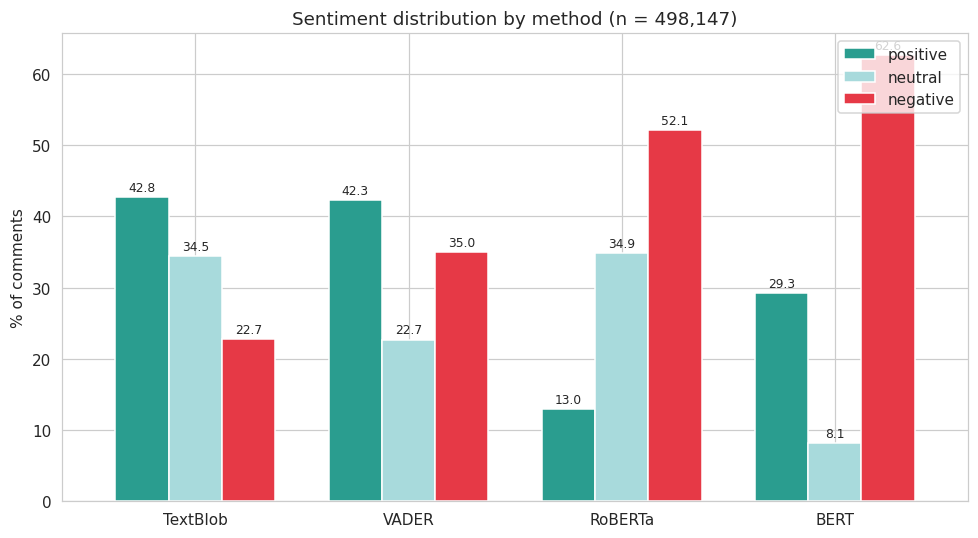

Range across methods (percentage points):
positive    29.8
neutral     26.8
negative    39.9
dtype: float64


In [ ]:
dist = pd.DataFrame({
    NICE[m]: df[f"{m}_label"].value_counts(normalize=True) for m in METHODS
}).reindex(CLASSES)

print("Label shares, full corpus (%):")
print((dist * 100).round(2), "\n")

ax = (dist * 100).T.plot(kind="bar", figsize=(9, 5), rot=0, width=0.75,
                         color=["#2A9D8F", "#A8DADC", "#E63946"])
ax.set_ylabel("% of comments"); ax.set_xlabel("")
ax.set_title(f"Sentiment distribution by method (n = {len(df):,})")
ax.legend(title=None, loc="upper right")
for c in ax.containers:
    ax.bar_label(c, fmt="%.1f", fontsize=8, padding=2)
plt.tight_layout(); plt.show()

print("Range across methods (percentage points):")
print(((dist.max(axis=1) - dist.min(axis=1)) * 100).round(1))

**Result.** The methods produce fundamentally different pictures of the same corpus:

| | TextBlob | VADER | RoBERTa | BERT | Range |
|---|---|---|---|---|---|
| positive | 42.76% | 42.28% | 12.99% | 29.25% | 29.8 pts |
| neutral | 34.50% | 22.72% | 34.90% | 8.13% | 26.8 pts |
| negative | 22.74% | 35.00% | 52.12% | 62.62% | **39.9 pts** |

TextBlob reads the corpus as majority positive with 23% negative; BERT reads it as 63% negative. This is not a difference of degree — the two disagree about the basic character of the community being studied.

## Pairwise agreement

A single agreement percentage hides the structure of the disagreement, so the crosstab and the consensus counts are reported alongside it.

Pairwise agreement (%):
          TextBlob  VADER  RoBERTa   BERT
TextBlob     100.0   55.9     43.0   36.6
VADER         55.9  100.0     52.9   47.6
RoBERTa       43.0   52.9    100.0   56.2
BERT          36.6   47.6     56.2  100.0 



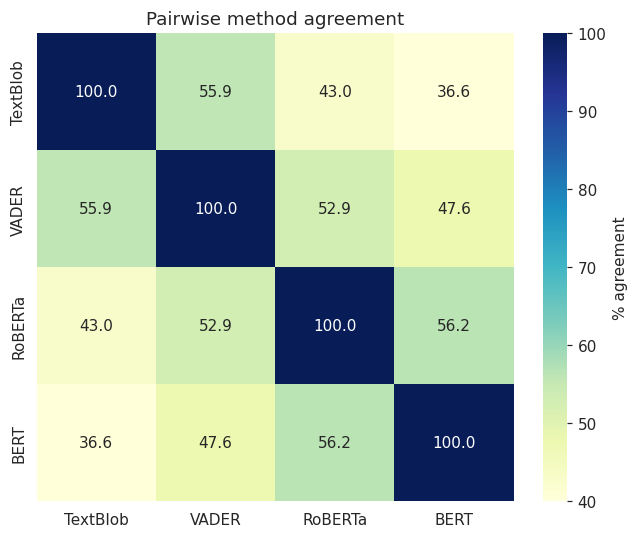

Distinct labels per comment across the 4 methods:
all 4 agree          97088
two labels          283984
all three labels    117075
Name: count, dtype: int64


In [ ]:
pairs = list(combinations(METHODS, 2))
agree = pd.DataFrame(index=[NICE[m] for m in METHODS],
                     columns=[NICE[m] for m in METHODS], dtype=float)

for m in METHODS:
    agree.loc[NICE[m], NICE[m]] = 1.0
for a, b in pairs:
    v = (df[f"{a}_label"] == df[f"{b}_label"]).mean()
    agree.loc[NICE[a], NICE[b]] = agree.loc[NICE[b], NICE[a]] = v

print("Pairwise agreement (%):")
print((agree * 100).round(1), "\n")

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(agree * 100, annot=True, fmt=".1f", cmap="YlGnBu",
            vmin=40, vmax=100, cbar_kws={"label": "% agreement"}, ax=ax)
ax.set_title("Pairwise method agreement")
plt.tight_layout(); plt.show()

# how many methods agree on each comment?
consensus = df[[f"{m}_label" for m in METHODS]].astype(str).nunique(axis=1)
print("Distinct labels per comment across the 4 methods:")
print(consensus.value_counts().sort_index()
        .rename({1: "all 4 agree", 2: "two labels", 3: "all three labels"}))

**Result.** All four methods assign the same label to only **97,088 comments — 19.5% of the corpus**. For 117,075 comments (23.5%), the four methods collectively produce every possible label.

Raw pairwise agreement ranges from 36.6% to 56.2%. The next cell shows why those figures need adjusting before they can be compared.

## Chance-corrected agreement

Raw agreement has a floor problem: two methods that both predict negative frequently will match often through coincidence alone, with no real correspondence between their judgments. Cohen's kappa adjusts for the agreement expected by chance given each method's class proportions.

The second half of this cell tests a specific hypothesis — that agreement tracks how negative each method is, rather than which family it belongs to.

Cohen's kappa (chance-corrected):
          TextBlob  VADER  RoBERTa   BERT
TextBlob     1.000  0.332    0.192  0.100
VADER        0.332  1.000    0.310  0.179
RoBERTa      0.192  0.310    1.000  0.278
BERT         0.100  0.179    0.278  1.000 



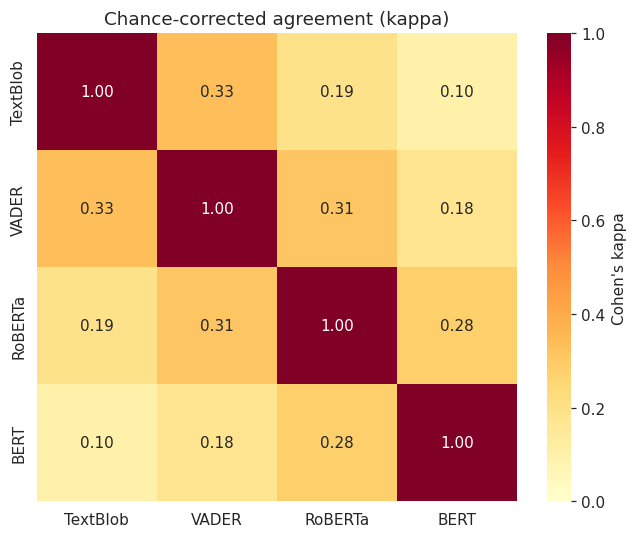

Methods ordered by negativity:
  TextBlob   22.7%
  VADER      35.0%
  RoBERTa    52.1%
  BERT       62.6%

Kappa by separation on that ordering:
  TextBlob  vs VADER      gap=1  kappa=0.33
  TextBlob  vs RoBERTa    gap=2  kappa=0.19
  TextBlob  vs BERT       gap=3  kappa=0.10
  VADER     vs RoBERTa    gap=1  kappa=0.31
  VADER     vs BERT       gap=2  kappa=0.18
  RoBERTa   vs BERT       gap=1  kappa=0.28


In [ ]:
# ---- Chance-corrected agreement (Cohen's kappa) ------------------
from sklearn.metrics import cohen_kappa_score

kappa = pd.DataFrame(index=[NICE[m] for m in METHODS],
                     columns=[NICE[m] for m in METHODS], dtype=float)
for m in METHODS:
    kappa.loc[NICE[m], NICE[m]] = 1.0
for a, b in combinations(METHODS, 2):
    k = cohen_kappa_score(df[f"{a}_label"].astype(str),
                          df[f"{b}_label"].astype(str))
    kappa.loc[NICE[a], NICE[b]] = kappa.loc[NICE[b], NICE[a]] = k

print("Cohen's kappa (chance-corrected):")
print(kappa.round(3), "\n")

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(kappa, annot=True, fmt=".2f", cmap="YlOrRd", vmin=0, vmax=1,
            cbar_kws={"label": "Cohen's kappa"}, ax=ax)
ax.set_title("Chance-corrected agreement (kappa)")
plt.tight_layout(); plt.show()

# does agreement track position on the negativity spectrum?
neg_rate = {m: (df[f"{m}_label"] == "negative").mean() for m in METHODS}
order = sorted(METHODS, key=lambda m: neg_rate[m])
print("Methods ordered by negativity:")
for m in order:
    print(f"  {NICE[m]:10s} {neg_rate[m]:.1%}")
print("\nKappa by separation on that ordering:")
for a, b in combinations(METHODS, 2):
    d = abs(order.index(a) - order.index(b))
    print(f"  {NICE[a]:9s} vs {NICE[b]:9s}  gap={d}  "
          f"kappa={kappa.loc[NICE[a], NICE[b]]:.2f}")

**Result.** The adjustment changes the conclusion. RoBERTa and BERT have the highest raw agreement of any pair at 56.2%, which makes them look like the closest match. After correcting for chance, the two lexicons correspond more closely (κ = 0.332 against 0.278) — the transformers only appeared close because both lean heavily negative, inflating coincidental matches.

Every pair falls in the "slight" or "fair" band. None reaches moderate agreement:

| Pair | Raw | Kappa |
|---|---|---|
| TextBlob – VADER | 55.9% | 0.332 |
| VADER – RoBERTa | 52.9% | 0.310 |
| RoBERTa – BERT | 56.2% | 0.278 |
| TextBlob – RoBERTa | 43.0% | 0.192 |
| VADER – BERT | 47.6% | 0.179 |
| TextBlob – BERT | 36.6% | 0.100 |

**The structure is one-dimensional.** Ordering the methods by negativity — TextBlob 22.7%, VADER 35.0%, RoBERTa 52.1%, BERT 62.6% — agreement declines monotonically with distance along that line: 0.33 / 0.31 / 0.28 for adjacent pairs, 0.19 / 0.18 for pairs two apart, 0.10 at opposite ends.

Model family is therefore not the organising variable. VADER and RoBERTa — one lexicon, one transformer — agree more with each other than the two transformers do.

## Sample versus full corpus

All four methods now cover the full corpus, so the earlier sample-based results can be checked directly against it. This validates the sampling approach used in notebooks 1 and 2, and by extension the sampling of the human-coded benchmark.

In [ ]:
samp_ids  = set(pd.read_parquet(PATHS["sample"], columns=["comment_id"])["comment_id"])
in_sample = df["comment_id"].isin(samp_ids)
print(f"Sample rows matched: {in_sample.sum():,} (expect {SAMPLE_N:,})")

rows = []
for m in METHODS:
    f = df[f"{m}_label"].value_counts(normalize=True).reindex(CLASSES)
    s = df.loc[in_sample, f"{m}_label"].value_counts(normalize=True).reindex(CLASSES)
    for c in CLASSES:
        rows.append({"method": NICE[m], "class": c,
                     "full %": f[c]*100, "sample %": s[c]*100,
                     "diff (pp)": (s[c]-f[c])*100})

val = pd.DataFrame(rows).set_index(["method", "class"]).round(2)
print(val, "\n")
print(f"Max absolute deviation: {val['diff (pp)'].abs().max():.2f} pp")

Sample rows matched: 100,000 (expect 100,000)
                   full %  sample %  diff (pp)
method   class                                
TextBlob positive   42.76     43.03       0.26
         neutral    34.50     34.17      -0.33
         negative   22.74     22.80       0.07
VADER    positive   42.28     42.44       0.16
         neutral    22.72     22.83       0.11
         negative   35.00     34.73      -0.27
RoBERTa  positive   12.99     13.14       0.15
         neutral    34.90     35.00       0.10
         negative   52.12     51.86      -0.25
BERT     positive   29.25     29.22      -0.03
         neutral     8.13      8.33       0.19
         negative   62.62     62.45      -0.16 

Max absolute deviation: 0.33 pp


## Illustrative divergences

Concrete examples of where the methods disagree. The second group — comments TextBlob calls positive and RoBERTa calls negative — is the clearest illustration of the lexicon failure mode, and these quotes are more useful in a written report than any distribution chart.

In [ ]:
show = ["comment_id", "sent_text"] + [f"{m}_label" for m in METHODS]

print("=== All four methods disagree maximally (3 distinct labels) ===")
for t in df.loc[consensus == 3].sample(6, random_state=RANDOM_SEED)["sent_text"]:
    print(f"  • {t[:150]}")

print("\n=== TextBlob positive, RoBERTa negative ===")
mask = (df["tb_label"] == "positive") & (df["roberta_label"] == "negative")
print(f"({mask.sum():,} comments, {mask.mean():.1%} of corpus)")
for t in df.loc[mask].sample(6, random_state=RANDOM_SEED)["sent_text"]:
    print(f"  • {t[:150]}")

=== All four methods disagree maximally (3 distinct labels) ===
  • She's not even an insurance lol she's a broker. I mean they're cool for some but a middle man gets a cut , research yourself and save that money But y
  • That's assuming people use those names, which they don't. Most of us just call it "the 5." Even if we did use those names, the shield signs will tell 
  • You saying you wouldn't pay $500 in taxes if doing so made the $500 insurance premium go away?
  • The absolute terror with which this struck 8 year old me is something I will never forget. During that summer, I spent each night under my covers tryi
  • There's no world where the majority of high density areas in LA would be desirable places to live. Slums would form across many areas. The rich would 
  • If you're slightly famous USC will accept and pass you lol, just like if you're rich.

=== TextBlob positive, RoBERTa negative ===
(91,929 comments, 18.5% of corpus)
  • Do you know how long it takes? Some people 

---
# Validating the Topic Labels

Topic assignments come from the project's topic modelling workstream: an LDA model with five topics, fitted over the full corpus and reproduced independently for this analysis.

Supplied labels are checked against each topic's content rather than adopted directly. This matters because a mislabelled topic would misdirect the interpretation of its sentiment score.

In [ ]:
print("Topic sizes:")
print(df["topic_label"].value_counts(), "\n")

for t in sorted(df["topic_id"].unique()):
    sub = df[df["topic_id"] == t].nlargest(8, "topic_prob")
    print(f"\n===== TOPIC {t}: {sub['topic_label'].iloc[0]} =====")
    for _, r in sub.iterrows():
        print(f"  [{r['topic_prob']:.2f}] {r['sent_text'][:130]}")

Topic sizes:
topic_label
Housing Affordability and Urban Issues          126908
Neighborhoods and Living Conditions             104443
Politics and Public Policy                       94345
General Discussions and Everyday Experiences     91442
Community and Local Events                       81009
Name: count, dtype: int64 


===== TOPIC 0: Housing Affordability and Urban Issues =====
  [0.97] As soon as they mandate “affordable housing”, you know the whole thing will be a failure. In fact, that might be the secret point.
  [0.96] City council members have a lot of influence and power over their district, more than the mayor in many cases. They are arguably m
  [0.96] We are not distrustful, we're informed, from attending and reporting on public corruption and land use hearings, breaking stories 
  [0.96] They're right though. Surveys and studies put the homeless population with underlying addiction and/or mental health issues anywhe
  [0.96] Affordable Housing and RSO are very differ

## Sampling a topic across confidence bands

The topic supplied as "Community and Local Events" did not match its characteristic terms, which include *police*, *stop*, and *ice* alongside *dog*, *love*, and *good*.

Reading only the highest-probability documents in a topic is misleading, because those documents are selected for being extreme rather than typical. Two readings based on small samples were discarded before this approach was applied: an initial reading of the terms suggested law enforcement, and a reading of the top documents suggested confrontational discourse. Sampling across three probability bands gives a more accurate picture.

In [ ]:
t4 = df[df["topic_id"] == 4]
print(t4["topic_prob"].describe().round(3))

for lo, hi in [(0.25, 0.40), (0.40, 0.60), (0.60, 0.90)]:
    band = t4[(t4["topic_prob"] >= lo) & (t4["topic_prob"] < hi)]
    print(f"\n===== topic_prob {lo}–{hi}  (n={len(band):,}) =====")
    for t in band.sample(min(8, len(band)), random_state=RANDOM_SEED)["sent_text"]:
        print(f"  • {t[:130]}")

count    81009.000
mean         0.489
std          0.139
min          0.200
25%          0.390
50%          0.457
75%          0.571
max          0.970
Name: topic_prob, dtype: float64

===== topic_prob 0.25–0.4  (n=22,970) =====
  • Hope those tariffs of yours can put a dent in that additional $300 Billion going to Iran 🙄
  • Yeah well as another fellow Jew we have 80% of our people LARP'ing as Nazis. The bulk of the rise in antisemitism is due to our ow
  • Exactly my point. Why is LA in the headline at the same time the president is raging against California and Los Angeles.
  • I was there and heard someone say that based on the language on the truck he is associated with "MEK". A leftist group that's been
  • Louis still got them fans even after jerk off gate
  • Eaton burned down an entire economic district, not to mention thousands of homes, and 19 people died.
  • It reminded me of something and it finally hit me. The autopsy table from “Bones”. PS: any MEs or Coroners out ther

**Result.** The topic contains reactive commentary on public affairs, figures, and events — tariffs, an election, a fire, a prison sentence, driving, sport — with no single unifying subject. It is relabelled **News Reactions and Opinion Commentary**.

Its assignment confidence is also the weakest of the five (mean 0.489, median 0.457 against a corpus median of 0.480), consistent with a topic the model is least certain about.

This validation established that **two of the five topics are residual groupings** without a coherent subject: this one, and General Discussions and Everyday Experiences. Sentiment figures for both reflect mixed content rather than attitude toward any particular thing, and they are reported separately from the three interpretable topics.

## Applying the relabel

In [ ]:
LABELS = {
    0: "Housing Affordability and Urban Issues",
    1: "Neighborhoods and Living Conditions",
    2: "General Discussions and Everyday Experiences",
    3: "Politics and Public Policy",
    4: "News Reactions and Opinion Commentary",
}

df["topic_label"] = df["topic_id"].map(LABELS).astype("category")
df.to_parquet(PATHS["merged"], index=False)

print(df["topic_label"].value_counts())

topic_label
Housing Affordability and Urban Issues          126908
Neighborhoods and Living Conditions             104443
Politics and Public Policy                       94345
General Discussions and Everyday Experiences     91442
News Reactions and Opinion Commentary            81009
Name: count, dtype: int64


---
# Human-Coded Benchmark

Because the four methods contradict each other on the basic character of the corpus, nothing in their output can determine which is closest to correct — the outputs are the thing being evaluated. An external reference is required, and hand-labelling is the only available source of one.

## Checking the completed annotations

Run after annotation, before any scoring. Verifies that every label is valid, splits the records back into Set A and Set B using the key file, and — where note tags were used — checks that similar cases received consistent labels.

A fourth label value, `unclear`, was available for comments that cannot be judged without the surrounding thread. Defaulting such comments to neutral was rejected as an option, because it would pad the neutral class with unreadable comments and penalise any model that correctly identified their sentiment.

In [ ]:
ann = pd.read_excel(PATHS["gold_annotate"], sheet_name="annotate")

# normalize casing/whitespace in case of typos
ann["gold_label"] = ann["gold_label"].astype(str).str.strip().str.lower()

print("Label distribution:")
print(ann["gold_label"].value_counts(dropna=False), "\n")

valid = {"positive", "neutral", "negative", "unclear"}
bad = ann[~ann["gold_label"].isin(valid)]
if len(bad):
    print("INVALID / MISSING:")
    print(bad[["row", "gold_label"]].to_string(index=False))
else:
    print("All 125 labels valid.\n")

# split back into Set A and Set B
key = pd.read_parquet(PATHS["gold_key"])
ann = ann.merge(key, on="comment_id", validate="one_to_one")
print(pd.crosstab(ann["gold_set"], ann["gold_label"]))

# consistency audit, if you used notes
if ann["notes"].notna().any():
    print("\nLabels by note tag:")
    print(ann[ann["notes"].notna()].groupby("notes")["gold_label"].value_counts())

Label distribution:
gold_label
negative    57
neutral     46
positive    22
Name: count, dtype: int64 

All 125 labels valid.

gold_label  negative  neutral  positive
gold_set                               
A                 44       37        19
B                 13        9         3

Labels by note tag:
notes    gold_label
factual  negative      1
insult   negative      1
mixed    neutral       1
         positive      1
sarcasm  negative      1
Name: count, dtype: int64


**Result.** All 125 labels valid, and `unclear` was not used, so no records are excluded.

Set A (n=100): **44 negative, 37 neutral, 19 positive**. This is the reference distribution the four methods are scored against.

Set B (n=25) came out 52% negative against Set A's 44%, and 12% positive against 19% — a different distribution, which is expected given it was selected for disagreement.

Only five records carried note tags, one per tag, so the consistency audit cannot run. Annotation consistency therefore rests on the work having been done in a single pass rather than on a statistical check, and this is recorded as a limitation.

## Joining annotations to predictions

`how="left"` with a null assertion is deliberate. An inner join would silently drop any benchmark record missing a prediction, leaving fewer records scored than intended; failing loudly is preferable to a quietly shrunken benchmark.

In [ ]:
from sklearn.metrics import (accuracy_score, f1_score, precision_recall_fscore_support,
                             confusion_matrix, classification_report)

ann = pd.read_excel(PATHS["gold_annotate"], sheet_name="annotate")
ann["gold_label"] = ann["gold_label"].astype(str).str.strip().str.lower()
assert ann["gold_label"].isin(CLASSES).all(), "Unexpected label value"

key  = pd.read_parquet(PATHS["gold_key"])
gold = (ann[["comment_id", "sent_text", "gold_label", "notes"]]
        .merge(key, on="comment_id", validate="one_to_one")
        .merge(df[["comment_id"] + [f"{m}_label" for m in METHODS]],
               on="comment_id", how="left", validate="one_to_one"))

assert gold[[f"{m}_label" for m in METHODS]].notna().all().all(), "Missing predictions"

for m in METHODS:
    gold[f"{m}_label"] = gold[f"{m}_label"].astype(str)

set_a = gold[gold["gold_set"] == "A"].copy()   # accuracy figures come ONLY from here
set_b = gold[gold["gold_set"] == "B"].copy()   # error analysis only

print(f"Set A: {len(set_a)} | Set B: {len(set_b)}")
print("\nSet A class balance:")
print(set_a["gold_label"].value_counts().reindex(CLASSES))

Set A: 100 | Set B: 25

Set A class balance:
gold_label
positive    19
neutral     37
negative    44
Name: count, dtype: int64


## Accuracy and macro-F1

Macro-F1 was specified in advance as the primary selection metric. It averages performance across the three classes equally rather than letting the largest class dominate, which matters when classes are imbalanced and a method can score well simply by over-predicting the majority.

Confidence intervals are reported because at n=100 they are wide enough to determine which differences can be claimed.

In [ ]:
rows = []
for m in METHODS:
    y_true, y_pred = set_a["gold_label"], set_a[f"{m}_label"]
    p, r, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=CLASSES, zero_division=0)
    rows.append({
        "Method":   NICE[m],
        "Accuracy": accuracy_score(y_true, y_pred),
        "Macro-F1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "F1 pos":   f1[0], "F1 neu": f1[1], "F1 neg": f1[2],
        "Rec pos":  r[0],  "Rec neu": r[1],  "Rec neg": r[2],
    })

perf = (pd.DataFrame(rows).set_index("Method")
          .sort_values("Macro-F1", ascending=False))
print("Set A performance (n = {}):\n".format(len(set_a)))
print((perf * 100).round(1))

best = perf.index[0]
print(f"\nBest by macro-F1: {best} ({perf.loc[best,'Macro-F1']:.3f})")

# 95% CI on accuracy — essential at n=100
n = len(set_a)
print(f"\n95% CI on accuracy (n={n}):")
for meth in perf.index:
    a = perf.loc[meth, "Accuracy"]
    half = 1.96 * np.sqrt(a * (1 - a) / n)
    print(f"  {meth:10s} {a:.1%}  ±{half:.1%}   [{a-half:.1%}, {a+half:.1%}]")

Set A performance (n = 100):

          Accuracy  Macro-F1  F1 pos  F1 neu  F1 neg  Rec pos  Rec neu  \
Method                                                                   
RoBERTa       70.0      70.3    72.7    64.1    74.2     63.2     67.6   
TextBlob      50.0      49.7    44.8    44.4    60.0     78.9     37.8   
VADER         49.0      47.2    43.8    37.7    60.2     73.7     27.0   
BERT          50.0      44.4    53.1    17.8    62.3     68.4     10.8   

          Rec neg  
Method             
RoBERTa      75.0  
TextBlob     47.7  
VADER        56.8  
BERT         75.0  

Best by macro-F1: RoBERTa (0.703)

95% CI on accuracy (n=100):
  RoBERTa    70.0%  ±9.0%   [61.0%, 79.0%]
  TextBlob   50.0%  ±9.8%   [40.2%, 59.8%]
  VADER      49.0%  ±9.8%   [39.2%, 58.8%]
  BERT       50.0%  ±9.8%   [40.2%, 59.8%]


**Result.** RoBERTa is clearly ahead; the other three are close together.

| Method | Accuracy | Macro-F1 | F1 pos | F1 neu | F1 neg |
|---|---|---|---|---|---|
| **RoBERTa** | **70.0%** | **70.3** | 72.7 | 64.1 | 74.2 |
| TextBlob | 50.0% | 49.7 | 44.8 | 44.4 | 60.0 |
| VADER | 49.0% | 47.2 | 43.8 | 37.7 | 60.2 |
| BERT | 50.0% | 44.4 | 53.1 | **17.8** | 62.3 |

**The metric choice was load-bearing.** TextBlob and BERT both score exactly 50% accuracy and would appear equivalent on that measure alone. Macro-F1 separates them by five points, entirely because BERT almost never identifies neutral content — its neutral F1 of 17.8 reflects catching 4 of the 37 neutral comments, a recall rate of 10.8%.

RoBERTa's confidence interval [61.0%, 79.0%] does not overlap any other method's. The other three overlap almost completely, so the one-point gaps between them carry no meaning.

## Confusion matrices

The loop after the plot names each method's most common error in a single line, which is more useful for reporting than asking a reader to interpret four heatmaps.

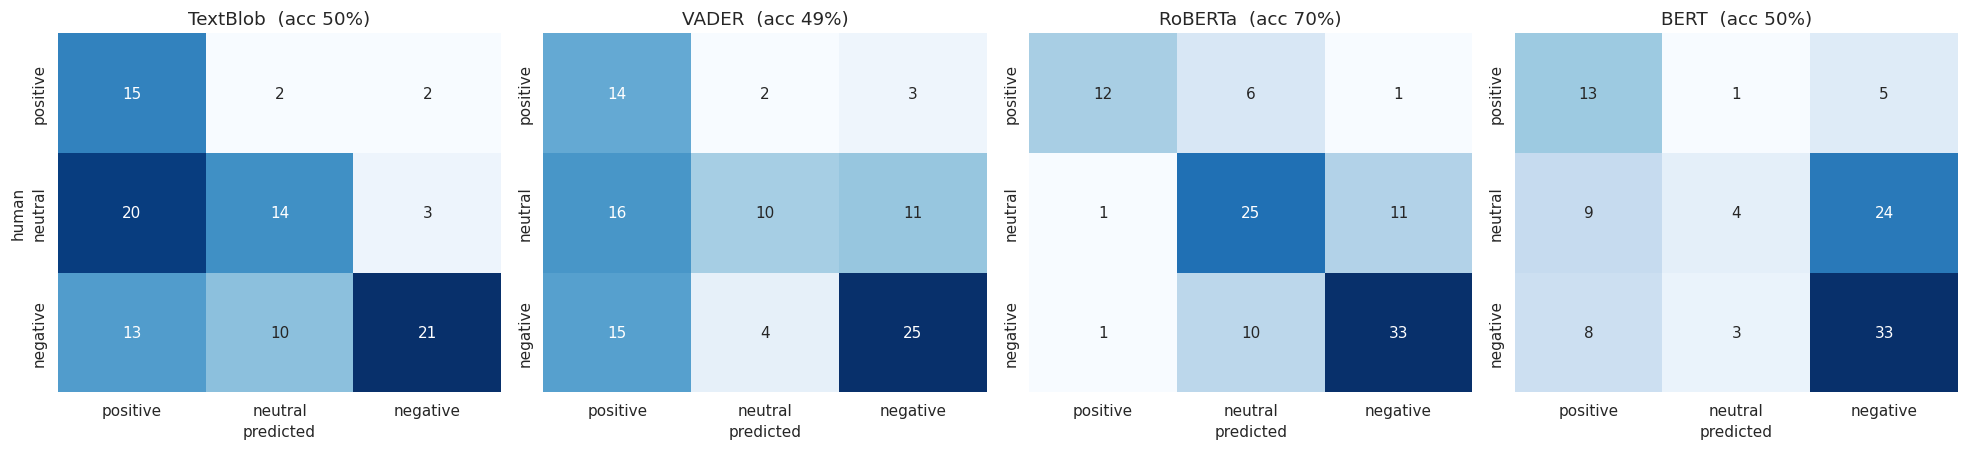

TextBlob   dominant error: human neutral → predicted positive  (20 of 100)
VADER      dominant error: human neutral → predicted positive  (16 of 100)
RoBERTa    dominant error: human neutral → predicted negative  (11 of 100)
BERT       dominant error: human neutral → predicted negative  (24 of 100)


In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4.2))
for ax, m in zip(axes, METHODS):
    cm = confusion_matrix(set_a["gold_label"], set_a[f"{m}_label"], labels=CLASSES)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=CLASSES, yticklabels=CLASSES, ax=ax)
    acc = accuracy_score(set_a["gold_label"], set_a[f"{m}_label"])
    ax.set_title(f"{NICE[m]}  (acc {acc:.0%})")
    ax.set_xlabel("predicted"); ax.set_ylabel("human" if m == METHODS[0] else "")
plt.tight_layout(); plt.show()

for m in METHODS:
    cm = confusion_matrix(set_a["gold_label"], set_a[f"{m}_label"], labels=CLASSES)
    off = [(CLASSES[i], CLASSES[j], cm[i, j])
           for i in range(3) for j in range(3) if i != j]
    t, p, c = max(off, key=lambda x: x[2])
    print(f"{NICE[m]:10s} dominant error: human {t} → predicted {p}  ({c} of {len(set_a)})")

**Result.** Every method's dominant error involves neutral comments, but the two families fail in opposite directions:

| Method | Most common error | Count of 100 |
|---|---|---|
| TextBlob | neutral → positive | 20 |
| VADER | neutral → positive | 16 |
| BERT | neutral → negative | 24 |
| RoBERTa | neutral → negative | 11 |

The lexicons find positive vocabulary inside factual comments and conclude they are positive. The transformers read unpleasant subject matter and conclude the writer is upset. RoBERTa makes the transformer error at less than half BERT's rate.

A more serious failure appears in the corners of the lexicon matrices. TextBlob labelled **13 genuinely negative comments as positive**, and VADER labelled **15** that way. RoBERTa did this once. These are outright reversals, and they follow directly from scoring word by word without regard to negation, sarcasm, or context.

## Testing whether the differences are real

Ranking by score is not sufficient at this sample size. Each pair of methods is compared on only the records where they disagreed, testing whether the split of those disagreements departs from chance.

In [ ]:
from itertools import combinations

print("Pairwise comparison on Set A (McNemar-style):\n")
correct = {m: (set_a[f"{m}_label"] == set_a["gold_label"]).values for m in METHODS}

for a, b in combinations(METHODS, 2):
    only_a = int((correct[a] & ~correct[b]).sum())
    only_b = int((~correct[a] & correct[b]).sum())
    n_disc = only_a + only_b
    if n_disc == 0:
        continue
    # exact binomial two-sided p under H0: p=0.5
    from scipy.stats import binomtest
    p = binomtest(only_a, n_disc, 0.5).pvalue
    star = "*" if p < 0.05 else " "
    print(f"{NICE[a]:10s} vs {NICE[b]:10s}: "
          f"{only_a:3d} / {only_b:3d} discordant  p={p:.3f} {star}")

Pairwise comparison on Set A (McNemar-style):

TextBlob   vs VADER     :  17 /  16 discordant  p=1.000  
TextBlob   vs RoBERTa   :  10 /  30 discordant  p=0.002 *
TextBlob   vs BERT      :  19 /  19 discordant  p=1.000  
VADER      vs RoBERTa   :   6 /  27 discordant  p=0.000 *
VADER      vs BERT      :  15 /  16 discordant  p=1.000  
RoBERTa    vs BERT      :  31 /  11 discordant  p=0.003 *


**Result.** RoBERTa is significantly better than all three alternatives — against VADER (27 to 6, p = 0.000), TextBlob (30 to 10, p = 0.002), and BERT (31 to 11, p = 0.003).

Every comparison among the other three returns p = 1.000, with near-perfectly balanced discordant counts (17/16, 19/19, 16/15). They are statistically indistinguishable.

The honest summary is therefore **RoBERTa first, then a three-way tie** — not a four-way ranking. Reporting the raw ordering without this test would imply differences between the lower three that the evidence does not support.

## Error analysis on Set B

Set B was selected for maximum disagreement, so these are the hardest comments in the corpus. Because at least one method had to be right by construction, the distribution of correct counts is a property of the selection rather than a finding.

In [ ]:
set_b["n_correct"] = sum((set_b[f"{m}_label"] == set_b["gold_label"]).astype(int)
                         for m in METHODS)

print("How many of the 4 methods got each Set B comment right:")
print(set_b["n_correct"].value_counts().sort_index(), "\n")

print("=== Comments ALL FOUR methods got wrong ===")
for _, r in set_b[set_b["n_correct"] == 0].iterrows():
    preds = " ".join(f"{NICE[m][:4]}={r[f'{m}_label'][:3]}" for m in METHODS)
    print(f"\n  human={r['gold_label']} | {preds}")
    print(f"  {r['sent_text'][:200]}")

print("\n\n=== Only the best method got it right ===")
best_key = [k for k, v in NICE.items() if v == best][0]
mask = (set_b["n_correct"] == 1) & (set_b[f"{best_key}_label"] == set_b["gold_label"])
for _, r in set_b[mask].iterrows():
    print(f"\n  human={r['gold_label']}")
    print(f"  {r['sent_text'][:200]}")

How many of the 4 methods got each Set B comment right:
n_correct
1    13
2    12
Name: count, dtype: int64 

=== Comments ALL FOUR methods got wrong ===


=== Only the best method got it right ===

  human=negative
  This whole country is the Wild West now.

  human=negative
  “You are an unfit mother.”

  human=neutral
  In the 90s he investigated Bill Clinton's alleged perjury in regards to his affair with Monica Lewinsky and it served to be the basis of Clinton's impeachment. Didn't know people were still salty abou

  human=neutral
  You still think Pahlavi wants a throne when he has said time and time again both in persian and English that he does not want to become the monarch. He's even said that after the goverment type is dec

  human=neutral
  Have you seen the cost of soda lately? A 36 pack of cans at a Costco business center in the Midwest was $18.99 today in the Midwest. Is that 50c a can, sure. But when soda was $1.75 at a restaurant, i

  human=neutral
  AB 253: Califor

**Result.** RoBERTa was the only correct method on **8 of the 13** comments that just one method got right.

Five of those eight share a pattern: factual or explanatory writing about a charged subject. A verbatim summary of California Assembly Bill 253; an account of the Clinton impeachment investigation written as history; arithmetic about the price of soda. Every other method assigned a sentiment to these; RoBERTa alone read them as reporting rather than opinion.

The remaining three are short negatives containing no negative vocabulary at all — *"This whole country is the Wild West now"* and the quoted line *"You are an unfit mother."* Neither can be scored correctly by looking up individual words.

These 25 records are deliberately hard cases and are **not** a second accuracy estimate. They illustrate how each method fails; the figures above describe general performance.

## Model selected

Twitter-RoBERTa is used for the topic analysis: 20 points more accurate than any alternative, significantly better than all three, the only method that identifies neutral content reliably, and making reversal errors at a fraction of the lexicon rate.

Two limitations carry forward. It labels roughly 30% of individual comments incorrectly, so it is dependable in aggregate but not for any single comment. And it leans about 14 points more negative than the hand-labelled sample, so absolute sentiment levels are overstated even though comparisons between groups remain valid.

In [ ]:
gold.to_parquet(BASE / "gold_set_scored.parquet", index=False)
perf.to_csv(BASE / "phase5_performance.csv")

BEST_METHOD = best_key
print(f"BEST_METHOD = {BEST_METHOD!r} ({best})")
print("Saved gold_set_scored.parquet and phase5_performance.csv")

BEST_METHOD = 'roberta' (RoBERTa)
Saved gold_set_scored.parquet and phase5_performance.csv


---
# Sentiment Trends by Topic

## Aggregation

Topics are ranked on **net sentiment** — the positive share minus the negative share, in percentage points.

Net sentiment is used rather than a mean of coded values because it disregards the neutral class entirely. Neutral accounts for roughly a third of RoBERTa's output and varies substantially between topics, so a measure that folded it in would conflate two different things: how critical a topic is, and how much of it is informational.

Both views are computed here — all assigned comments, and the subset assigned to their topic with at least 0.50 probability. Reporting both makes the influence of weakly assigned comments visible.

In [14]:
BEST = "roberta"          # from Phase 5
LBL  = f"{BEST}_label"

def summarise(frame, name):
    """Class shares, net sentiment, and volume per topic."""
    ct = pd.crosstab(frame["topic_label"], frame[LBL], normalize="index")[CLASSES]
    out = (ct * 100).round(1)
    out["net"]    = (out["positive"] - out["negative"]).round(1)
    out["n"]      = frame["topic_label"].value_counts()
    out["% corp"] = (out["n"] / len(frame) * 100).round(1)
    out = out.sort_values("net")
    out.columns.name = name
    return out

full = summarise(df, "ALL")
hi   = summarise(df[df["topic_prob"] >= CONF_THRESHOLD], "HIGH-CONF")

print(f"=== All assigned comments (n = {len(df):,}) ===")
print(full, "\n")
print(f"=== topic_prob >= {CONF_THRESHOLD} (n = {(df['topic_prob'] >= CONF_THRESHOLD).sum():,}) ===")
print(hi)

=== All assigned comments (n = 498,147) ===
ALL                                           positive  neutral  negative  \
topic_label                                                                 
Politics and Public Policy                         9.0     32.1      58.9   
Housing Affordability and Urban Issues             9.6     33.3      57.2   
News Reactions and Opinion Commentary             12.2     30.0      57.8   
General Discussions and Everyday Experiences      17.7     34.6      47.7   
Neighborhoods and Living Conditions               17.2     43.5      39.3   

ALL                                            net       n  % corp  
topic_label                                                         
Politics and Public Policy                   -49.9   94345    18.9  
Housing Affordability and Urban Issues       -47.6  126908    25.5  
News Reactions and Opinion Commentary        -45.6   81009    16.3  
General Discussions and Everyday Experiences -30.0   91442    18.4  
Ne

**Result.** All five topics are net negative, spanning 27.8 points:

| Topic | Positive | Neutral | Negative | Net | Comments |
|---|---|---|---|---|---|
| Politics and Public Policy | 9.0% | 32.1% | 58.9% | **−49.9** | 94,345 |
| Housing Affordability and Urban Issues | 9.6% | 33.3% | 57.2% | −47.6 | 126,908 |
| News Reactions and Opinion Commentary | 12.2% | 30.0% | 57.8% | −45.6 | 81,009 |
| General Discussions and Everyday Experiences | 17.7% | 34.6% | 47.7% | −30.0 | 91,442 |
| Neighborhoods and Living Conditions | 17.2% | 43.5% | 39.3% | **−22.1** | 104,443 |

Restricting to the three interpretable topics, the pattern is that **criticism targets institutions rather than place**. Politics and housing policy draw sharp criticism; neighbourhoods, transit, and getting around the city draw far less.

Part of the mechanism is visible in the neutral column: Neighborhoods carries 43.5% neutral against Politics' 32.1%, because much of that topic is informational — which route to take, where to park, how the airport terminals are numbered.

With 81,000 to 127,000 comments per topic, every gap here is far larger than sampling variation.

## Robustness check 1 — the confidence filter

LDA assignments in this corpus are diffuse: the median comment is only about 2.4 times more likely to belong to its assigned topic than to a topic chosen at random. If weak assignments were driving the ranking, restricting to confident ones would change it.

In [15]:
cmp = pd.DataFrame({
    "net (all)":  full["net"],
    "net (hi)":   hi["net"],
    "n (all)":    full["n"],
    "n (hi)":     hi["n"],
})
cmp["Δ net"]     = (cmp["net (hi)"] - cmp["net (all)"]).round(1)
cmp["rank all"]  = cmp["net (all)"].rank().astype(int)
cmp["rank hi"]   = cmp["net (hi)"].rank().astype(int)
print(cmp.sort_values("net (all)"), "\n")

same = (cmp["rank all"] == cmp["rank hi"]).all()
print("Ranking identical under both views:", same)
print("Spearman rho:", round(cmp["net (all)"].corr(cmp["net (hi)"], method="spearman"), 3))

                                              net (all)  net (hi)  n (all)  \
topic_label                                                                  
Politics and Public Policy                        -49.9     -47.5    94345   
Housing Affordability and Urban Issues            -47.6     -44.6   126908   
News Reactions and Opinion Commentary             -45.6     -42.0    81009   
General Discussions and Everyday Experiences      -30.0     -24.7    91442   
Neighborhoods and Living Conditions               -22.1     -14.4   104443   

                                              n (hi)  Δ net  rank all  rank hi  
topic_label                                                                     
Politics and Public Policy                     45398    2.4         1        1  
Housing Affordability and Urban Issues         59035    3.0         2        2  
News Reactions and Opinion Commentary          33663    3.6         3        3  
General Discussions and Everyday Experiences   3

**Result.** The ranking is identical under both views — Spearman ρ = 1.0. Every topic shifts in the same direction (+2.4 to +7.7 points), so weakly assigned comments were making the whole corpus look slightly more negative without changing which topics rank where.

## Chart

Two panels because they answer different questions: composition shows how much neutral each topic carries, net sentiment shows the ranking.

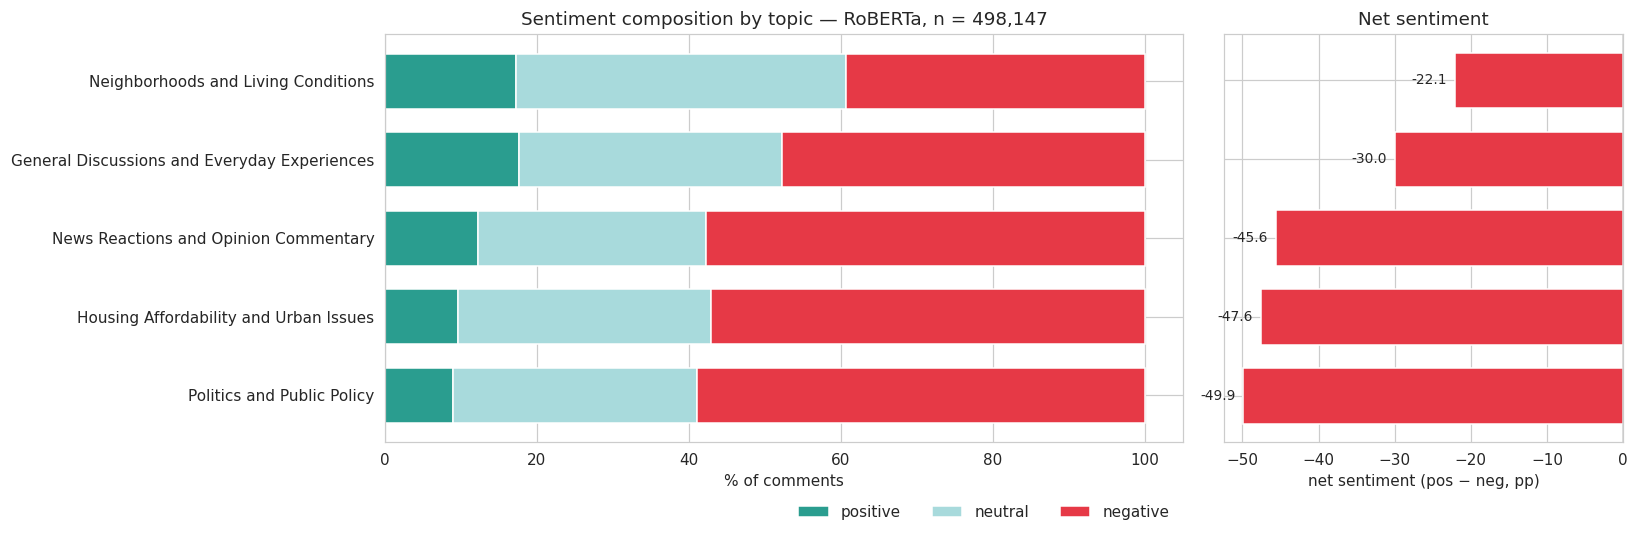

In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5),
                               gridspec_kw={"width_ratios": [2, 1]})

full[CLASSES].plot(kind="barh", stacked=True, ax=ax1,
                   color=["#2A9D8F", "#A8DADC", "#E63946"], width=0.7)
ax1.set_xlabel("% of comments"); ax1.set_ylabel("")
ax1.set_title(f"Sentiment composition by topic — {NICE[BEST]}, n = {len(df):,}")
ax1.legend(title=None, bbox_to_anchor=(1.0, -0.12), ncol=3, frameon=False)

colors = ["#E63946" if v < 0 else "#2A9D8F" for v in full["net"]]
ax2.barh(full.index, full["net"], color=colors, height=0.7)
ax2.axvline(0, color="black", lw=0.8)
ax2.set_yticklabels([])          # shares the left panel's labels
ax2.set_xlabel("net sentiment (pos − neg, pp)")
ax2.set_title("Net sentiment")
for i, v in enumerate(full["net"]):
    ax2.text(v + (1 if v >= 0 else -1), i, f"{v:+.1f}",
             va="center", ha="left" if v >= 0 else "right", fontsize=9)

plt.tight_layout(); plt.show()

## Interpretable topics only

The two residual topics identified during label validation are separated out. Neither has a coherent subject, so reporting either as "the community feels X about Y" would be wrong.

In [17]:
RESIDUAL = ["General Discussions and Everyday Experiences",
            "News Reactions and Opinion Commentary"]

interp = full[~full.index.isin(RESIDUAL)]
print("Interpretable topics only (0, 1, 3):\n")
print(interp, "\n")
print(f"Spread across interpretable topics: "
      f"{interp['net'].max() - interp['net'].min():.1f} pp")
print(f"Residual topics net: "
      f"{full.loc[RESIDUAL, 'net'].to_dict()}")

Interpretable topics only (0, 1, 3):

ALL                                     positive  neutral  negative   net  \
topic_label                                                                 
Politics and Public Policy                   9.0     32.1      58.9 -49.9   
Housing Affordability and Urban Issues       9.6     33.3      57.2 -47.6   
Neighborhoods and Living Conditions         17.2     43.5      39.3 -22.1   

ALL                                          n  % corp  
topic_label                                             
Politics and Public Policy               94345    18.9  
Housing Affordability and Urban Issues  126908    25.5  
Neighborhoods and Living Conditions     104443    21.0   

Spread across interpretable topics: 27.8 pp
Residual topics net: {'General Discussions and Everyday Experiences': -30.0, 'News Reactions and Opinion Commentary': -45.6}


## Robustness check 2 — top-level comments versus replies

Roughly two thirds of the corpus are replies to other comments rather than to the original post. A reply's sentiment may be aimed at another commenter rather than at the topic, which could distort topic-level figures.

In [18]:
df["is_reply"] = df["parent_id"].str.startswith("t1_")

rep = pd.DataFrame({
    "top-level": summarise(df[~df["is_reply"]], "t")["net"],
    "reply":     summarise(df[df["is_reply"]], "r")["net"],
})
rep["Δ"] = (rep["reply"] - rep["top-level"]).round(1)
print(f"Replies: {df['is_reply'].mean():.1%} of corpus\n")
print(rep.sort_values("top-level"))

Replies: 65.7% of corpus

                                              top-level  reply    Δ
topic_label                                                        
Politics and Public Policy                        -47.5  -51.0 -3.5
Housing Affordability and Urban Issues            -45.6  -48.3 -2.7
News Reactions and Opinion Commentary             -42.7  -47.4 -4.7
General Discussions and Everyday Experiences      -27.0  -32.0 -5.0
Neighborhoods and Living Conditions               -19.3  -23.8 -4.5


**Result.** Replies are more negative in every topic, by between 2.7 and 5.0 points. Because the effect is consistent across topics, it shifts the overall level rather than changing the comparison between them. The ranking is unaffected.

This does not remove the concern — reply sentiment genuinely may be aimed at people rather than topics — but it establishes that the effect is a constant offset rather than a confound.

## Robustness check 3 — sentiment over time

If the ranking were an artifact of averaging across the whole period, plotting it month by month would show topics crossing.

/tmp/ipykernel_5853/2166133097.py:5: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  d["month"] = d["created_dt"].dt.to_period("M").dt.to_timestamp()


Corpus span: 300 days, 11 months


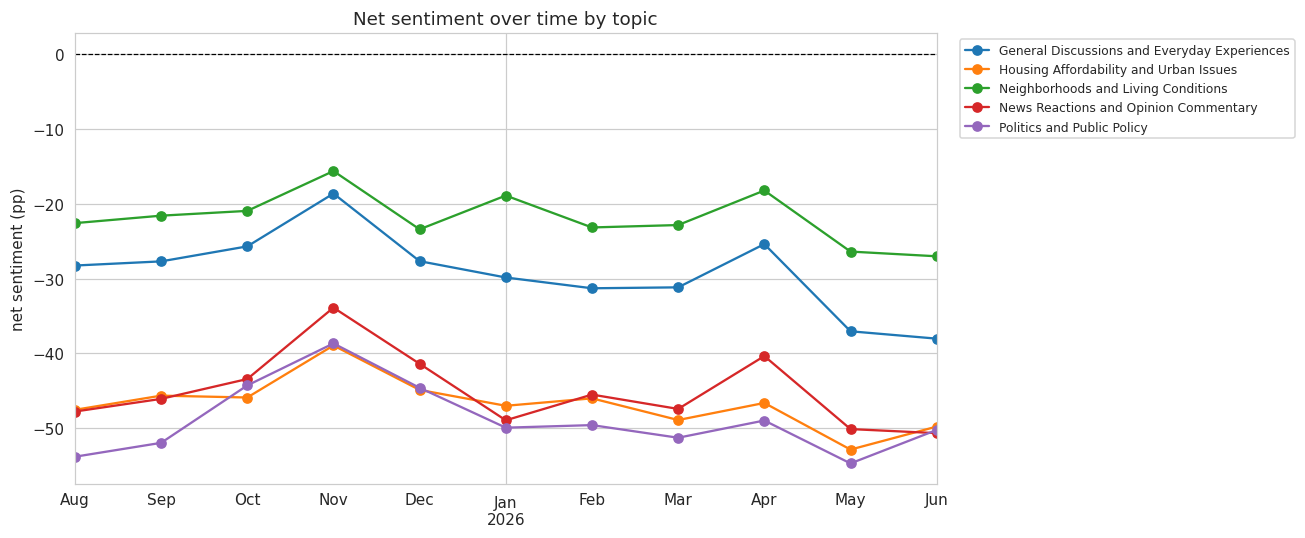

In [19]:
ts = pd.read_parquet(PATHS["scored"], columns=["comment_id", "created_utc"])
d = df.merge(ts, on="comment_id", validate="one_to_one")
d["created_dt"] = pd.to_datetime(
    d["created_utc"].str.replace(" UTC", "", regex=False), utc=True)
d["month"] = d["created_dt"].dt.to_period("M").dt.to_timestamp()

span = (d["created_dt"].max() - d["created_dt"].min()).days
print(f"Corpus span: {span} days, {d['month'].nunique()} months")

if d["month"].nunique() >= 4:
    monthly = (d.groupby(["month", "topic_label"], observed=True)[LBL]
                 .value_counts(normalize=True).unstack()
                 .assign(net=lambda x: (x["positive"] - x["negative"]) * 100)
                 ["net"].unstack())
    ax = monthly.plot(figsize=(12, 5), marker="o", lw=1.5)
    ax.axhline(0, color="black", lw=0.8, ls="--")
    ax.set_ylabel("net sentiment (pp)"); ax.set_xlabel("")
    ax.set_title("Net sentiment over time by topic")
    ax.legend(fontsize=8, bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout(); plt.show()
else:
    print("Span too short for a monthly series — skip.")

**Result.** Across all eleven months, **no topic ever overtakes another**. Politics and housing remain the most critical in every month; neighbourhoods remains the least critical in every month.

One corpus-wide movement is visible: November 2025 is the least negative month for all five topics simultaneously, with the largest shift in News Reactions (a 15-point improvement from October). A change affecting every topic at once indicates a corpus-level event rather than a topic-level one, and the timing coincides with the Los Angeles municipal election, which appears throughout the political content. Sentiment returns to prior levels by December.

A second movement appears at the end of the series, where Neighborhoods and General Discussions both decline from April to June while the policy topics stay flat. This has not been attributed to a specific cause.

## Saving

In [20]:
full.to_csv(BASE / "phase7_sentiment_by_topic_all.csv")
hi.to_csv(BASE / "phase7_sentiment_by_topic_highconf.csv")
print("Saved both views.")

Saved both views.


---
## Outputs

| File | Contents |
|---|---|
| `all_scores_merged.parquet` | All four methods plus topic assignments, 498,147 records |
| `gold_set_scored.parquet` | The 125 hand-labelled records with all four methods' predictions |
| `phase5_performance.csv` | Accuracy and F1 per method |
| `phase7_sentiment_by_topic_all.csv` | By-topic summary, all assigned comments |
| `phase7_sentiment_by_topic_highconf.csv` | By-topic summary, confidence ≥ 0.50 |

## Findings

**Method comparison.** The four methods span 39.9 percentage points on the negative class over identical text. All four agree on only 19.5% of comments, and no pair reaches moderate chance-corrected agreement. Agreement tracks position on a negativity spectrum rather than model family.

**Model selection.** Twitter-RoBERTa: 70.0% accuracy and 70.3 macro-F1, significantly better than all three alternatives, which are statistically indistinguishable from each other at 44.4 to 49.7 macro-F1. The lexicon methods misclassify genuinely negative comments as positive 13 and 15 times out of 100; RoBERTa once.

**Sentiment by topic.** Politics (−49.9) and housing (−47.6) are the most critical topics; neighbourhoods (−22.1) the least, a 27.8-point spread. The ranking survives a confidence filter, a top-level versus reply split, and a month-by-month breakdown. Absolute levels are overstated by roughly 14 points relative to the hand-labelled sample; relative comparisons are unaffected.